数据集形状: (1500, 34)

前5行数据预览:
      job_id           job_title       职位名称      job_category    职位类别  \
0  AIJOB0001  AI Agent Developer   AI 代理开发者    AI Engineering  人工智能工程   
1  AIJOB0002     Prompt Engineer      提示工程师    AI Engineering  人工智能工程   
2  AIJOB0003        LLM Engineer  大型语言模型工程师    AI Engineering  人工智能工程   
3  AIJOB0004  Data Engineer (AI)   AI 数据工程师  Data Engineering    数据工程   
4  AIJOB0005  AI Product Manager    AI 产品经理           Product      产品   

   experience_level       经验等级  years_of_experience    education_required  \
0  Senior (6-9 yrs)  高级 (6-9年)                    7              Master's   
1  Senior (6-9 yrs)  高级 (6-9年)                    2            Bachelor's   
2  Senior (6-9 yrs)  高级 (6-9年)                    4           Associate's   
3  Senior (6-9 yrs)  高级 (6-9年)                    3            Bachelor's   
4    Lead (10+ yrs)  领导 (10+年)                    5  Bootcamp/Self-taught   

     要求教育  ...  ai_salary_premium_pct  demand_score  demand_growth_yoy

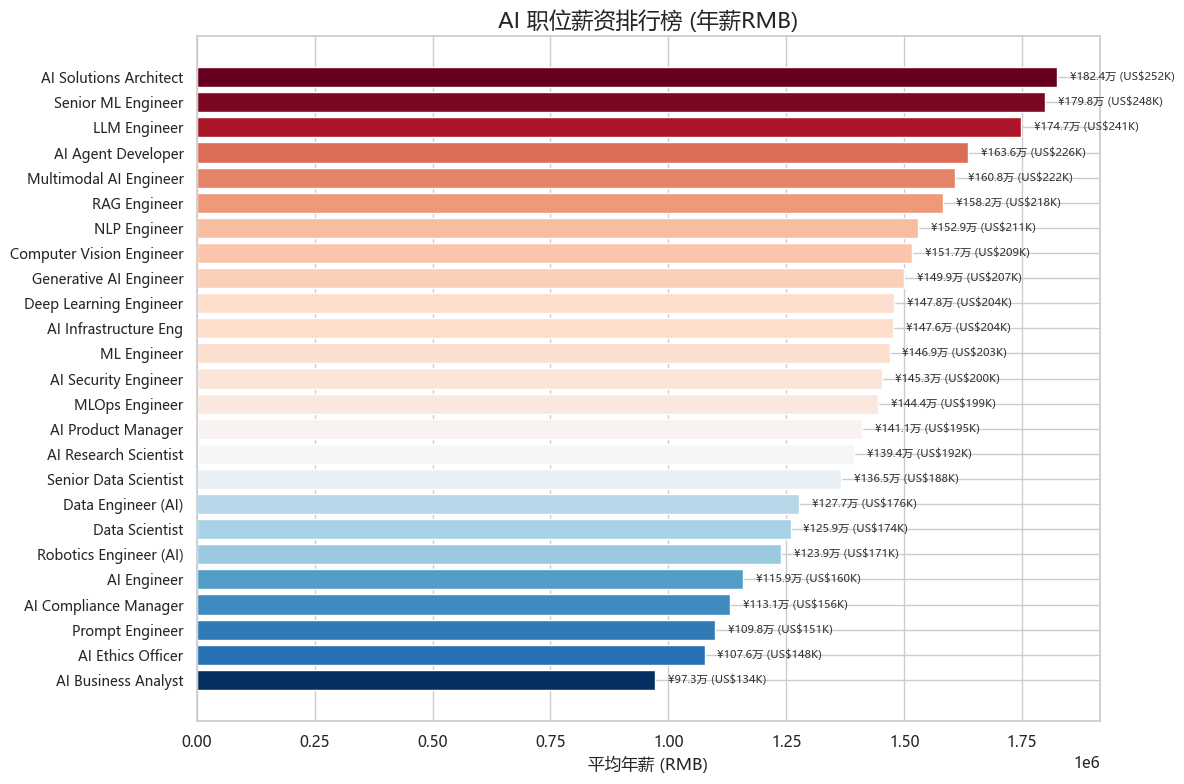


处理后的数据已保存为 'ai_jobs_2025_2026_processed.csv'


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体和绘图风格
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 1. 读取数据
# 请确保文件路径正确，这里假设文件在当前工作目录下
file_path = 'ai_jobs_market_2025到2026.xlsx'
df = pd.read_excel(file_path, sheet_name='ai_jobs_market_2025_2026')

# 2. 数据预览与清洗
print("数据集形状:", df.shape)
print("\n前5行数据预览:")
print(df.head())

# 检查缺失值
print("\n各列缺失值统计:")
print(df.isnull().sum())

# 3. 关键：货币转换 (USD -> CNY)
# 2026年5月的估算汇率 (1 USD ≈ 7.25 CNY)
exchange_rate = 7.25

# 创建新的人民币薪资列
df['salary_min_cny'] = df['salary_min_usd'] * exchange_rate
df['salary_max_cny'] = df['salary_max_usd'] * exchange_rate
df['annual_salary_cny'] = df['annual_salary_usd'] * exchange_rate

# 4. 核心分析：按国家和职位类别的薪资统计
# 这里的列名使用你上传文件中的英文列名
print("\n" + "="*50)
print("2025-2026年AI岗位薪资分析报告 (按国家/地区)")
print("="*50)

# 按国家/地区分组，计算平均年薪
country_salary = df.groupby('country')['annual_salary_cny'].agg(['count', 'mean', 'min', 'max']).round(0)
country_salary.columns = ['岗位数量', '平均年薪(万RMB)', '最低年薪(万RMB)', '最高年薪(万RMB)']
country_salary[['平均年薪(万RMB)', '最低年薪(万RMB)', '最高年薪(万RMB)']] = (country_salary[['平均年薪(万RMB)', '最低年薪(万RMB)', '最高年薪(万RMB)']] / 10000).round(1)
print(country_salary)

# 5. 按职位类别分析 (AI Engineering, Data Science 等)
print("\n" + "-"*50)
print("热门AI岗位类别薪资对比")
print("-"*50)

job_category_analysis = df.groupby('job_category')['annual_salary_cny'].agg(['count', 'mean']).round(0)
job_category_analysis.columns = ['岗位数量', '平均年薪(RMB)']
job_category_analysis = job_category_analysis.sort_values(by='平均年薪(RMB)', ascending=False)
print(job_category_analysis)

# 5.5 职位薪资排行榜可视化
job_salary_rank = df.groupby('job_title')['annual_salary_cny'].mean().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
colors = plt.cm.RdBu_r([(v - job_salary_rank.min()) / (job_salary_rank.max() - job_salary_rank.min()) for v in job_salary_rank.values])
bars = plt.barh(range(len(job_salary_rank)), job_salary_rank.values, color=colors)
plt.yticks(range(len(job_salary_rank)), job_salary_rank.index.tolist(), fontsize=10)
plt.xlabel('平均年薪 (RMB)', fontsize=12)
plt.title('AI 职位薪资排行榜 (年薪RMB)', fontsize=16)

for i, (v, usd) in enumerate(zip(job_salary_rank.values,
    df.groupby('job_title')['annual_salary_usd'].mean().loc[job_salary_rank.index].values)):
    plt.text(v + max(job_salary_rank.values) * 0.015, i,
             f'¥{v/10000:.1f}万 (US${usd/1000:.0f}K)', va='center', fontsize=8, color='#333333')

plt.tight_layout()
plt.show()

# 6. 保存处理后的数据 (可选)
df.to_csv('ai_jobs_2025_2026_processed.csv', index=False, encoding='utf-8-sig')
print("\n处理后的数据已保存为 'ai_jobs_2025_2026_processed.csv'")

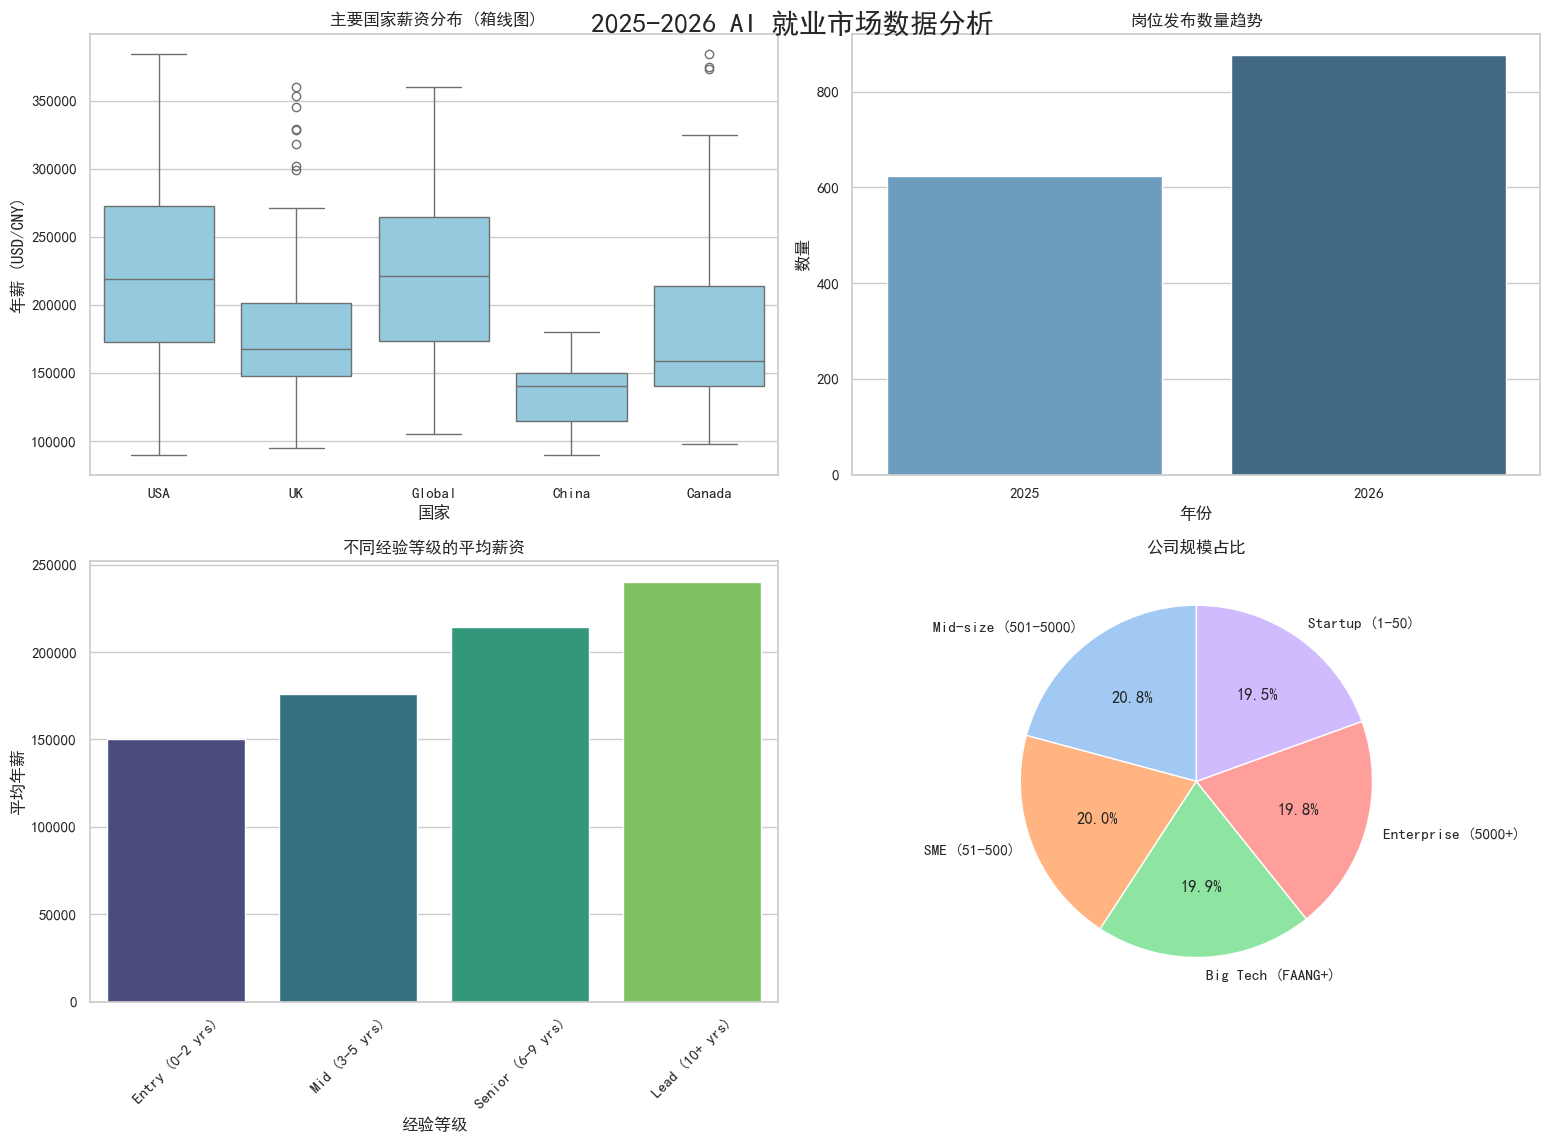

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 解决中文乱码的核心设置 ---
# 尝试使用系统自带的黑体，兼容性最好
plt.rcParams['font.sans-serif'] = ['SimHei', 'Heiti TC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# --- 2. 读取数据 ---
try:
    df = pd.read_excel('ai_jobs_market_2025到2026.xlsx')
except FileNotFoundError:
    print("未找到文件，请检查文件名是否正确。")
    exit()

# --- 3. 数据预处理 (简单清洗) ---
# 假设数据里有 "country" 和 "annual_salary_usd" 列
# 简单区分一下国内外（根据你的数据实际情况调整）
# 这里为了演示，我们只看有薪资数据的行
df = df.dropna(subset=['annual_salary_usd', 'country'])

# --- 4. 开始绘图 ---
# 创建一个大的画布，分成 2x2 四个区域
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('2025-2026 AI 就业市场数据分析', fontsize=20, y=0.95)

# --- 图1：箱线图 - 不同国家的薪资分布 ---
# 取前5个岗位最多的国家
top_countries = df['country'].value_counts().index[:5]
df_top = df[df['country'].isin(top_countries)]

# 修复 Seaborn 警告：使用 color 代替 palette，或者确保 hue 正确
sns.boxplot(
    x='country',
    y='annual_salary_usd',
    data=df_top,
    ax=axes[0, 0],
    color='#87CEEB'  # 使用单一颜色避免 palette 警告
)
axes[0, 0].set_title('主要国家薪资分布 (箱线图)')
axes[0, 0].set_xlabel('国家')
axes[0, 0].set_ylabel('年薪 (USD/CNY)')

# --- 图2：柱状图 - 每年岗位数量 ---
year_counts = df['posting_year'].value_counts().sort_index()
sns.barplot(
    x=year_counts.index.astype(str),
    y=year_counts.values,
    ax=axes[0, 1],
    hue=year_counts.index.astype(str),
    palette="Blues_d",
    legend=False
)
axes[0, 1].set_title('岗位发布数量趋势')
axes[0, 1].set_xlabel('年份')
axes[0, 1].set_ylabel('数量')

# --- 图3：经验等级薪资对比 ---
# 假设有一列叫 experience_level
if 'experience_level' in df.columns:
    exp_salary = df.groupby('experience_level')['annual_salary_usd'].mean().sort_values()
    sns.barplot(
        x=exp_salary.index,
        y=exp_salary.values,
        ax=axes[1, 0],
        hue=exp_salary.index,
        palette="viridis",
        legend=False
    )
    axes[1, 0].set_title('不同经验等级的平均薪资')
    axes[1, 0].set_xlabel('经验等级')
    axes[1, 0].set_ylabel('平均年薪')
    axes[1, 0].tick_params(axis='x', rotation=45)

# --- 图4：公司规模分布 ---
if 'company_size' in df.columns:
    size_counts = df['company_size'].value_counts()
    axes[1, 1].pie(
        size_counts.values,
        labels=size_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette("pastel")
    )
    axes[1, 1].set_title('公司规模占比')

# 自动调整间距，防止重叠
plt.tight_layout()
plt.show()

c:\Users\ych\anaconda__related\anaconda--body\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


✅ 成功加载数据：共 21320 行
🔄 正在清洗数据...

📊 开始生成全景分析报告...


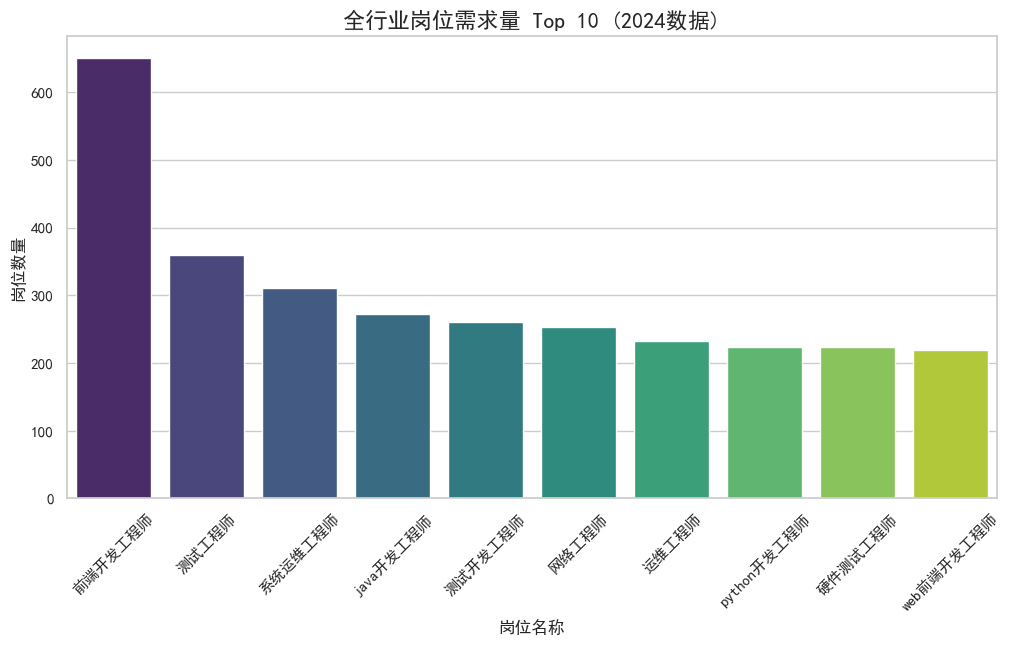

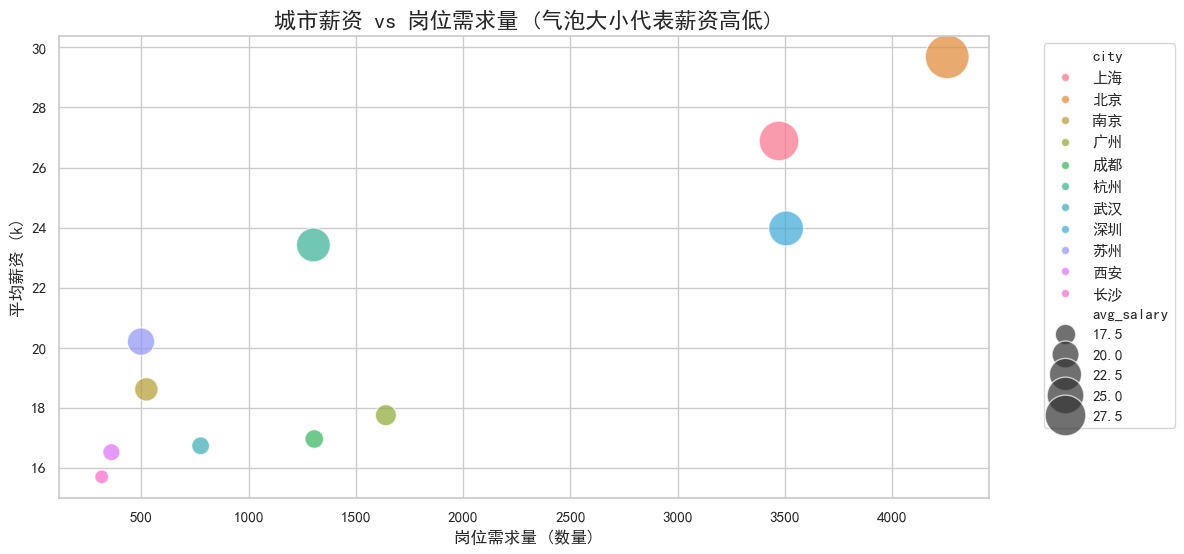

🔍 正在扫描全行业技术关键词...


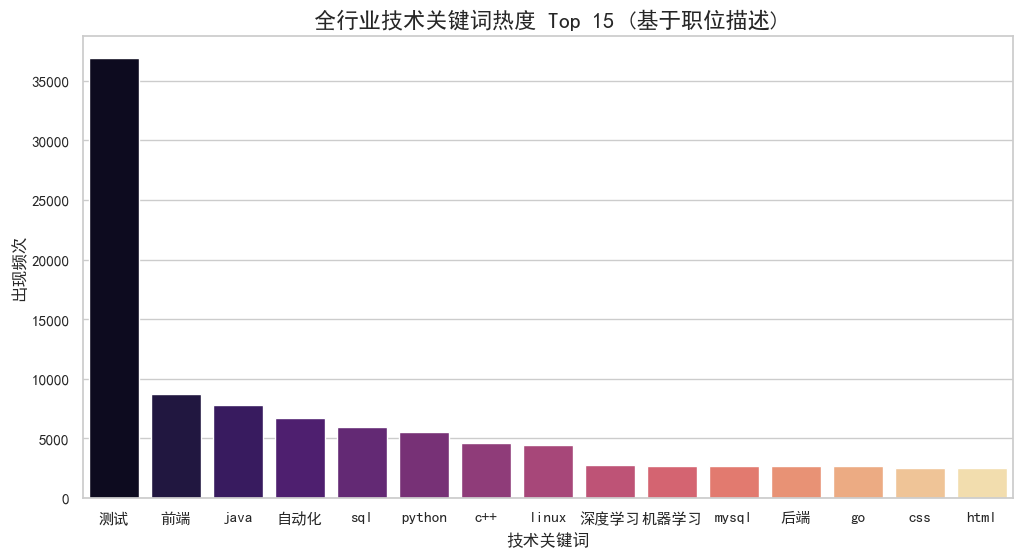

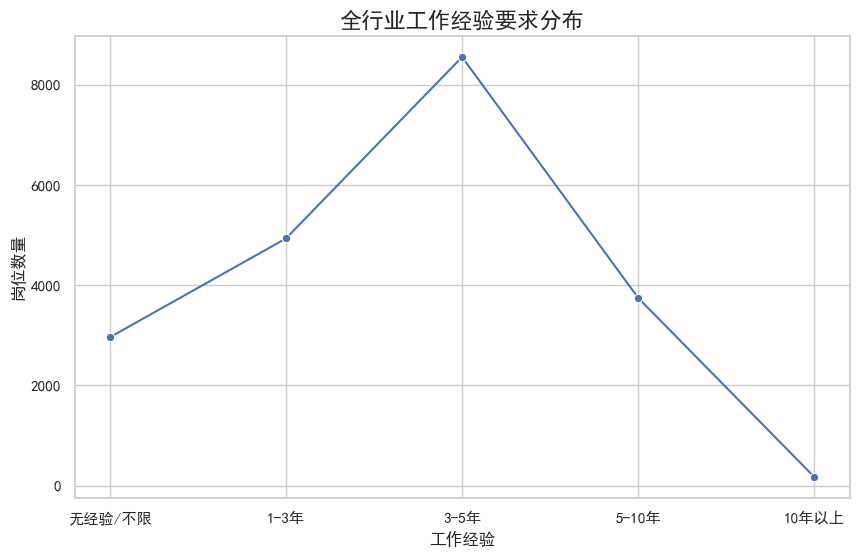

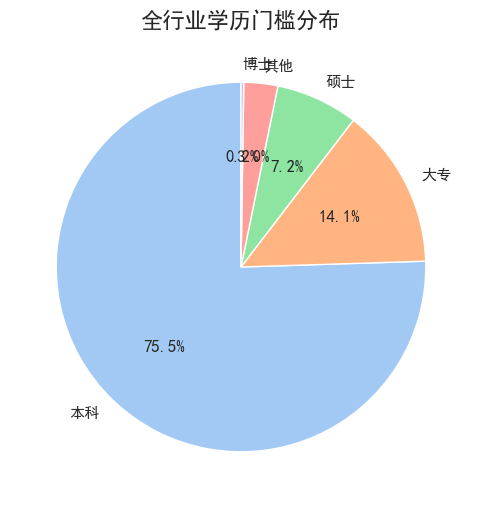

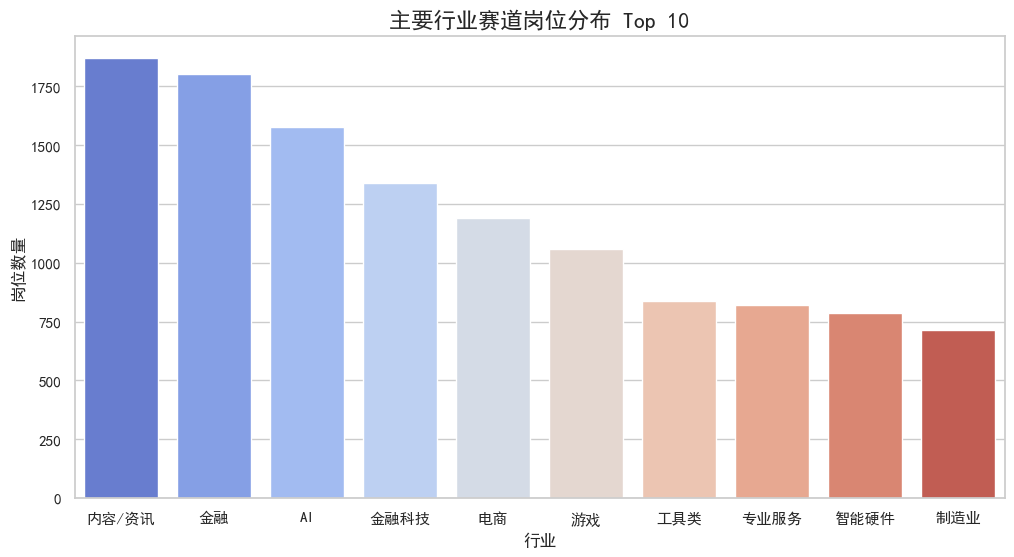

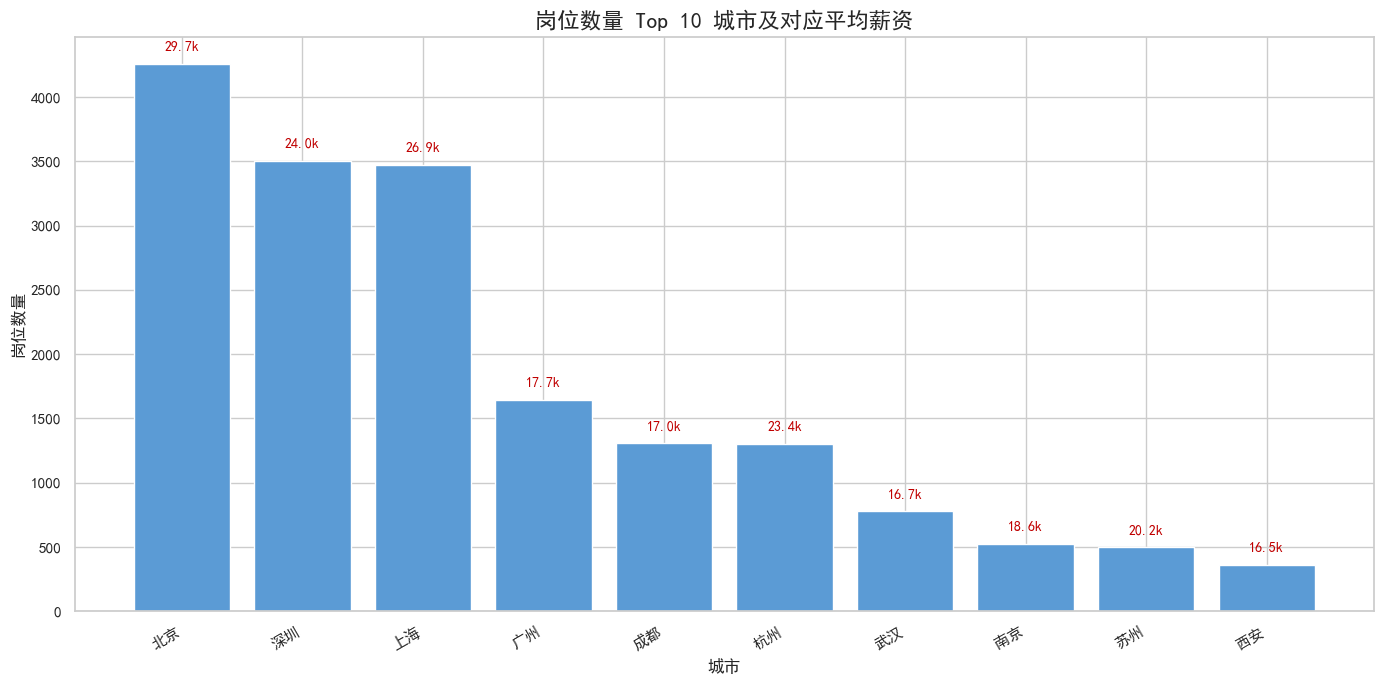

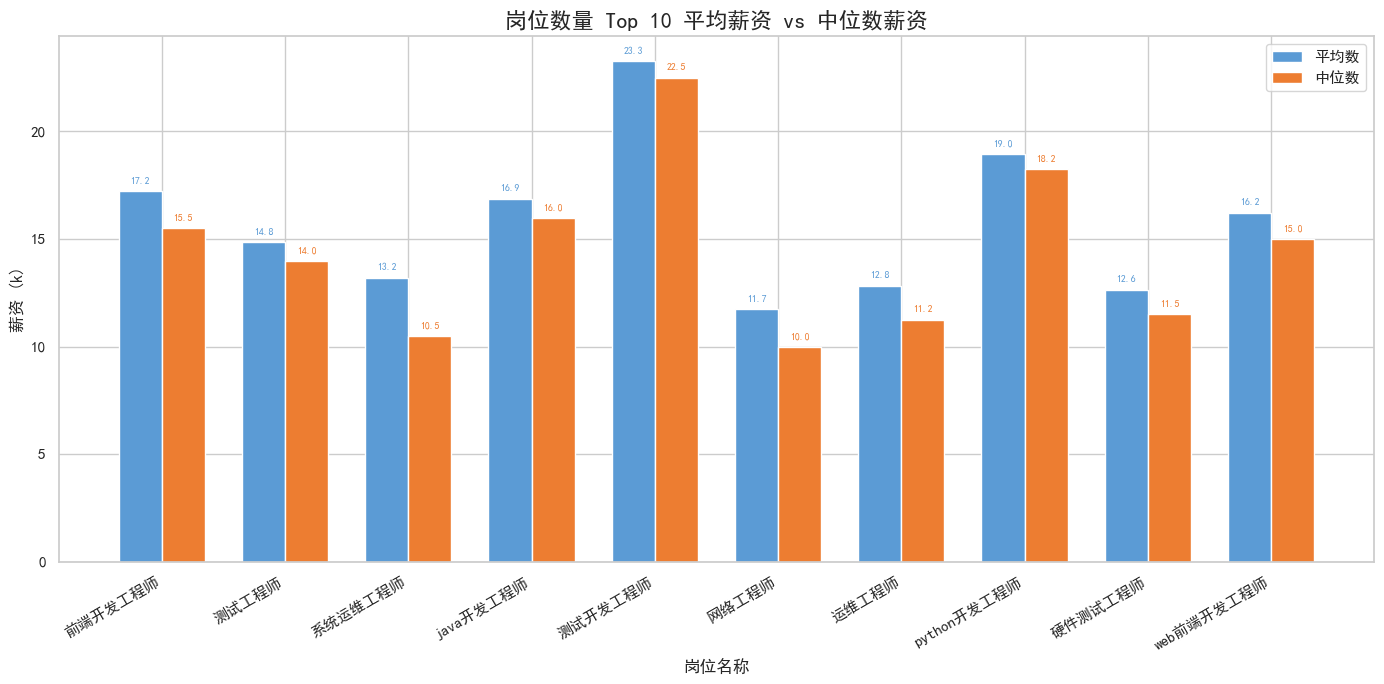

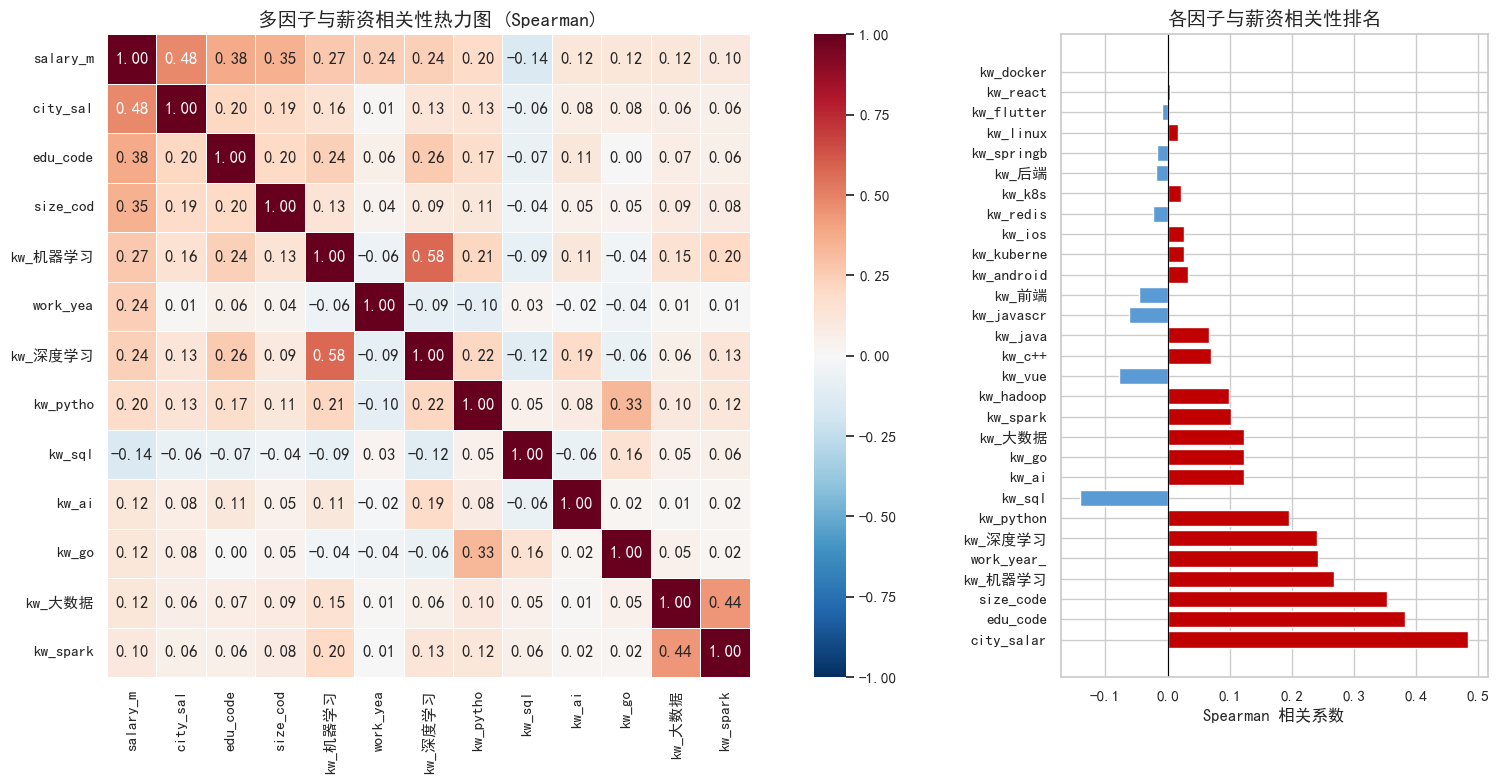

✅ 分析完成！


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import jieba

# --- 1. 基础配置 ---
# 设置绘图风格和中文字体
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# --- 2. 数据加载与清洗函数 ---
def load_and_clean_data(file_path):
    try:
        df = pd.read_excel(file_path)
        print(f"✅ 成功加载数据：共 {len(df)} 行")
    except FileNotFoundError:
        print(f"❌ 错误：未找到文件 '{file_path}'，请检查文件名或路径。")
        return None

    # 2.1 薪资处理：将 '15k-30k' 转换为 平均薪资 (22.5)
    def extract_salary(s):
        if not isinstance(s, str): return 0
        # 统一转小写
        s = s.lower()
        # 提取数字
        nums = re.findall(r'(\d+\.?\d*)k', s)
        if len(nums) == 2:
            return (float(nums[0]) + float(nums[1])) / 2
        elif len(nums) == 1:
            return float(nums[0])
        return 0

    # 2.2 清洗经验字段 (如 '3-5年' -> '3-5年', '无需经验' -> '无经验')
    def clean_exp(s):
        if not isinstance(s, str): return '未知'
        s = s.strip()
        if '无需' in s or '不限' in s: return '无经验/不限'
        return s

    # 2.3 清洗学历字段
    def clean_edu(s):
        if not isinstance(s, str): return '未知'
        s = s.strip()
        # 统一格式
        if '本科' in s: return '本科'
        if '大专' in s: return '大专'
        if '硕士' in s: return '硕士'
        if '博士' in s: return '博士'
        return '其他'

    # 应用清洗
    print("🔄 正在清洗数据...")
    df['salary_mean'] = df['salary'].apply(extract_salary)
    df['workYear_clean'] = df['workYear'].apply(clean_exp)
    df['edu_clean'] = df['education'].apply(clean_edu)

    # 过滤掉薪资为0的异常值（有些可能是面议或数据缺失）
    df = df[df['salary_mean'] > 0]

    return df

# --- 3. 核心分析函数 ---
def analyze_market(df):
    # 3.1 岗位数量 Top 10 (全局视角)
    plt.figure(figsize=(12, 6))
    job_counts = df['positionName'].value_counts().head(10)
    sns.barplot(x=job_counts.index, y=job_counts.values, hue=job_counts.index, palette='viridis', legend=False)
    plt.title('全行业岗位需求量 Top 10 (2024数据)', fontsize=16)
    plt.ylabel('岗位数量')
    plt.xlabel('岗位名称')
    plt.xticks(rotation=45)
    plt.show()

    # 3.2 城市薪资与需求对比 (散点图)
    plt.figure(figsize=(12, 6))
    city_stats = df.groupby('city').agg({'salary_mean': 'mean', 'positionName': 'count'}).reset_index()
    city_stats.columns = ['city', 'avg_salary', 'job_count']
    # 筛选出岗位数大于200的城市，避免噪声
    city_stats = city_stats[city_stats['job_count'] > 200]

    sns.scatterplot(data=city_stats, x='job_count', y='avg_salary', size='avg_salary', hue='city', sizes=(100, 1000), alpha=0.7)
    plt.title('城市薪资 vs 岗位需求量 (气泡大小代表薪资高低)', fontsize=16)
    plt.xlabel('岗位需求量 (数量)')
    plt.ylabel('平均薪资 (k)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

    # 3.3 技术关键词词云/统计 (全局技能)
    # 定义需要统计的技术关键词库（根据你的数据特征，可以适当增减）
    keywords = [
        'java', 'python', 'c++', 'go', 'javascript', 'vue', 'react', 'sql', 'mysql',
        'redis', 'springboot', 'linux', 'docker', 'kubernetes', 'hadoop', 'spark',
        'android', 'ios', 'flutter', 'unity', 'c#', 'html', 'css', 'nodejs', 'ai',
        '机器学习', '深度学习', '大数据', '前端', '后端', '测试', '自动化'
    ]

    all_text = " ".join(df['positionDetail'].astype(str).tolist())
    # 简单统计出现次数
    skill_counter = {}
    print("🔍 正在扫描全行业技术关键词...")
    for word in keywords:
        count = all_text.lower().count(word.lower())
        if count > 0:
            skill_counter[word] = count

    # 排序并取 Top 15
    sorted_skills = sorted(skill_counter.items(), key=lambda x: x[1], reverse=True)[:15]

    plt.figure(figsize=(12, 6))
    sns.barplot(x=[x[0] for x in sorted_skills], y=[x[1] for x in sorted_skills], hue=[x[0] for x in sorted_skills], palette='magma', legend=False)
    plt.title('全行业技术关键词热度 Top 15 (基于职位描述)', fontsize=16)
    plt.ylabel('出现频次')
    plt.xlabel('技术关键词')
    plt.show()

    # 3.4 经验要求分布
    plt.figure(figsize=(10, 6))
    exp_order = ['无经验/不限', '1-3年', '3-5年', '5-10年', '10年以上']
    # 确保顺序正确
    df['workYear_clean'] = pd.Categorical(df['workYear_clean'], categories=exp_order, ordered=True)
    exp_counts = df['workYear_clean'].value_counts().sort_index()

    sns.lineplot(x=exp_counts.index, y=exp_counts.values, marker='o')
    plt.title('全行业工作经验要求分布', fontsize=16)
    plt.ylabel('岗位数量')
    plt.xlabel('工作经验')
    plt.show()

    # 3.5 学历门槛分布
    plt.figure(figsize=(8, 6))
    edu_counts = df['edu_clean'].value_counts()
    plt.pie(edu_counts, labels=edu_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    plt.title('全行业学历门槛分布', fontsize=16)
    plt.show()

    # 3.6 行业赛道分析
    industry_map = {
        '人工智能': 'AI', '科技金融': '金融科技', '金融': '金融', '游戏': '游戏',
        '电商': '电商', '内容': '内容/资讯', '企业服务': '企服', '医疗': '医疗',
        '智能硬件': '智能硬件', '制造业': '制造业', '专业服务': '专业服务',
        '消费生活': '消费生活', '教育': '教育', '工具类': '工具类'
    }
    if 'industryField' in df.columns:
        plt.figure(figsize=(12, 6))
        # 统计包含关键词的行业
        industry_counter = {}
        for key, label in industry_map.items():
            cnt = df['industryField'].astype(str).str.contains(key).sum()
            if cnt > 0:
                if label in industry_counter:
                    industry_counter[label] += cnt
                else:
                    industry_counter[label] = cnt

        # 排序
        sorted_ind = sorted(industry_counter.items(), key=lambda x: x[1], reverse=True)[:10]

        sns.barplot(x=[x[0] for x in sorted_ind], y=[x[1] for x in sorted_ind], hue=[x[0] for x in sorted_ind], palette='coolwarm', legend=False)
        plt.title('主要行业赛道岗位分布 Top 10', fontsize=16)
        plt.ylabel('岗位数量')
        plt.xlabel('行业')
        plt.show()

    # 3.7 岗位数量 Top 10 地区薪资标注
    plt.figure(figsize=(14, 7))
    city_stats = df.groupby('city').agg(
        job_count=('positionName', 'count'),
        avg_salary=('salary_mean', 'mean')
    ).reset_index()
    city_top10 = city_stats.nlargest(10, 'job_count')

    bars = plt.bar(range(len(city_top10)), city_top10['job_count'].values, color='#5B9BD5')
    plt.xticks(range(len(city_top10)), city_top10['city'].values, rotation=30, ha='right')
    plt.ylabel('岗位数量')
    plt.xlabel('城市')
    plt.title('岗位数量 Top 10 城市及对应平均薪资', fontsize=16)

    # 在每个柱上标注平均薪资
    for i, (_, row) in enumerate(city_top10.iterrows()):
        salary_text = f'{row["avg_salary"]:.1f}k'
        plt.text(i, row['job_count'] + max(city_top10['job_count']) * 0.02,
                 salary_text, ha='center', va='bottom', fontsize=10, color='#C00000', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 3.8 岗位数量 Top 10 薪资中位数与平均数对比
    plt.figure(figsize=(14, 7))
    pos_stats = df.groupby('positionName').agg(
        job_count=('positionName', 'count'),
        avg_salary=('salary_mean', 'mean'),
        med_salary=('salary_mean', 'median')
    ).reset_index()
    pos_top10 = pos_stats.nlargest(10, 'job_count')

    x = range(len(pos_top10))
    width = 0.35
    plt.bar([i - width/2 for i in x], pos_top10['avg_salary'].values, width,
            label='平均数', color='#5B9BD5')
    plt.bar([i + width/2 for i in x], pos_top10['med_salary'].values, width,
            label='中位数', color='#ED7D31')
    plt.xticks(x, pos_top10['positionName'].values, rotation=30, ha='right')
    plt.ylabel('薪资 (k)')
    plt.xlabel('岗位名称')
    plt.title('岗位数量 Top 10 平均薪资 vs 中位数薪资', fontsize=16)
    plt.legend()

    for i, (_, row) in enumerate(pos_top10.iterrows()):
        plt.text(i - width/2, row['avg_salary'] + 0.3, f"{row['avg_salary']:.1f}",
                 ha='center', va='bottom', fontsize=7, color='#5B9BD5')
        plt.text(i + width/2, row['med_salary'] + 0.3, f"{row['med_salary']:.1f}",
                 ha='center', va='bottom', fontsize=7, color='#ED7D31')

    plt.tight_layout()
    plt.show()

    # 3.9 多因子与薪资相关性热力图
    heat_df = df.copy()

    # 公司规模编码
    size_map = {'少于15人': 1, '15-50人': 2, '50-150人': 3,
                '150-500人': 4, '500-2000人': 5, '2000人以上': 6}
    heat_df['size_code'] = heat_df['companySize'].map(size_map).fillna(0)

    # 学历编码
    edu_map = {'不限': 0, '大专': 1, '本科': 2, '硕士': 3, '博士': 4}
    heat_df['edu_code'] = heat_df['education'].map(edu_map).fillna(0)

    # 工作经验编码
    def parse_work_year(s):
        if not isinstance(s, str): return 0
        s = s.strip()
        if '不限' in s or '应届' in s: return 0
        if '无' in s: return 0
        nums = re.findall(r'(\d+)', s)
        if len(nums) >= 2:
            return (float(nums[0]) + float(nums[1])) / 2
        elif len(nums) == 1:
            return float(nums[0])
        return 0
    heat_df['work_year_num'] = heat_df['workYear'].apply(parse_work_year)

    # 城市薪资指数: 以各城市平均薪资作为编码
    city_salary_map = heat_df.groupby('city')['salary_mean'].mean()
    heat_df['city_salary_idx'] = heat_df['city'].map(city_salary_map)

    # 技术关键词标志位
    tech_keywords = [
        'java', 'python', 'c++', 'go', 'javascript', 'vue', 'react',
        'sql', 'redis', 'springboot', 'linux', 'docker', 'k8s', 'kubernetes',
        'spark', 'hadoop', 'android', 'ios', 'flutter',
        'ai', '机器学习', '深度学习', '大数据', '前端', '后端'
    ]
    for kw in tech_keywords:
        col_name = f'kw_{kw}'
        heat_df[col_name] = heat_df['positionDetail'].astype(str).str.lower().str.contains(kw.lower()).astype(int)

    # 构建相关矩阵
    feature_cols = (
        ['salary_mean', 'size_code', 'edu_code', 'work_year_num', 'city_salary_idx'] +
        [f'kw_{kw}' for kw in tech_keywords]
    )
    corr_df = heat_df[feature_cols].corr(method='spearman')

    # 只取 salary_mean 与其他因子的相关性, 按绝对值排序
    salary_corr = corr_df[['salary_mean']].drop('salary_mean')
    salary_corr = salary_corr.reindex(salary_corr['salary_mean'].abs().sort_values(ascending=False).index)

    # 绘制热力图
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8),
                                   gridspec_kw={'width_ratios': [3, 1]})

    # 左: 完整相关矩阵
    mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
    top_features = salary_corr.head(12).index.tolist()
    matrix_features = ['salary_mean'] + top_features
    matrix_corr = corr_df.loc[matrix_features, matrix_features]

    sns.heatmap(matrix_corr, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, square=True,
                linewidths=0.5, ax=ax1,
                xticklabels=[f[:8] for f in matrix_features],
                yticklabels=[f[:8] for f in matrix_features])
    ax1.set_title('多因子与薪资相关性热力图 (Spearman)', fontsize=14)

    # 右: 与薪资相关系数条形图
    colors = ['#C00000' if v > 0 else '#5B9BD5' for v in salary_corr['salary_mean'].values]
    ax2.barh(range(len(salary_corr)), salary_corr['salary_mean'].values, color=colors)
    ax2.set_yticks(range(len(salary_corr)))
    ax2.set_yticklabels([f[:10] for f in salary_corr.index])
    ax2.axvline(x=0, color='black', linewidth=0.8)
    ax2.set_xlabel('Spearman 相关系数')
    ax2.set_title('各因子与薪资相关性排名', fontsize=14)

    plt.tight_layout()
    plt.show()

# --- 主程序入口 ---
if __name__ == "__main__":
    # 请确保文件名与你的实际文件名一致
    file_name = 'it岗位  2024 国内.xlsx'
    data = load_and_clean_data(file_name)

    if data is not None:
        print("\n" + "="*30)
        print("📊 开始生成全景分析报告...")
        print("="*30)
        analyze_market(data)
        print("✅ 分析完成！")
    else:
        print("⚠️ 程序终止，因为数据加载失败。")

数据集形状: (138, 4)
数据量: 138 条

前5行预览:
            职位名称  工作经验  地点  年薪（K）
0  高性能计算工程师（多方向）  经验不限  上海    560
1  GPU调度研发工程师/专家  3-5年  上海    720
2      编译优化&架构方向  3-5年  上海    560
3        高性能计算专家  3-5年  上海    480
4           算子优化  3-5年  上海    360

基本统计:
count     138.000000
mean      544.094203
std       160.188342
min       250.000000
25%       480.000000
50%       500.000000
75%       560.000000
max      1500.000000
Name: 年薪（K）, dtype: float64

=== 职位领域分布 ===
职位领域
AI/大模型      37
其他          32
架构/管理       13
算法          12
基础技术        11
图形/多媒体       7
数据           6
安全           6
测试/质量        4
软件开发         3
通信/信号        2
运维/基础设施      2
金融科技         1
自动驾驶/机器人     1
产品/运营        1

=== 薪资档位分布 ===
薪资档位
450-550K    75
350-450K    24
550-650K    22
650-800K     9
800K以上       6
300K以下       2


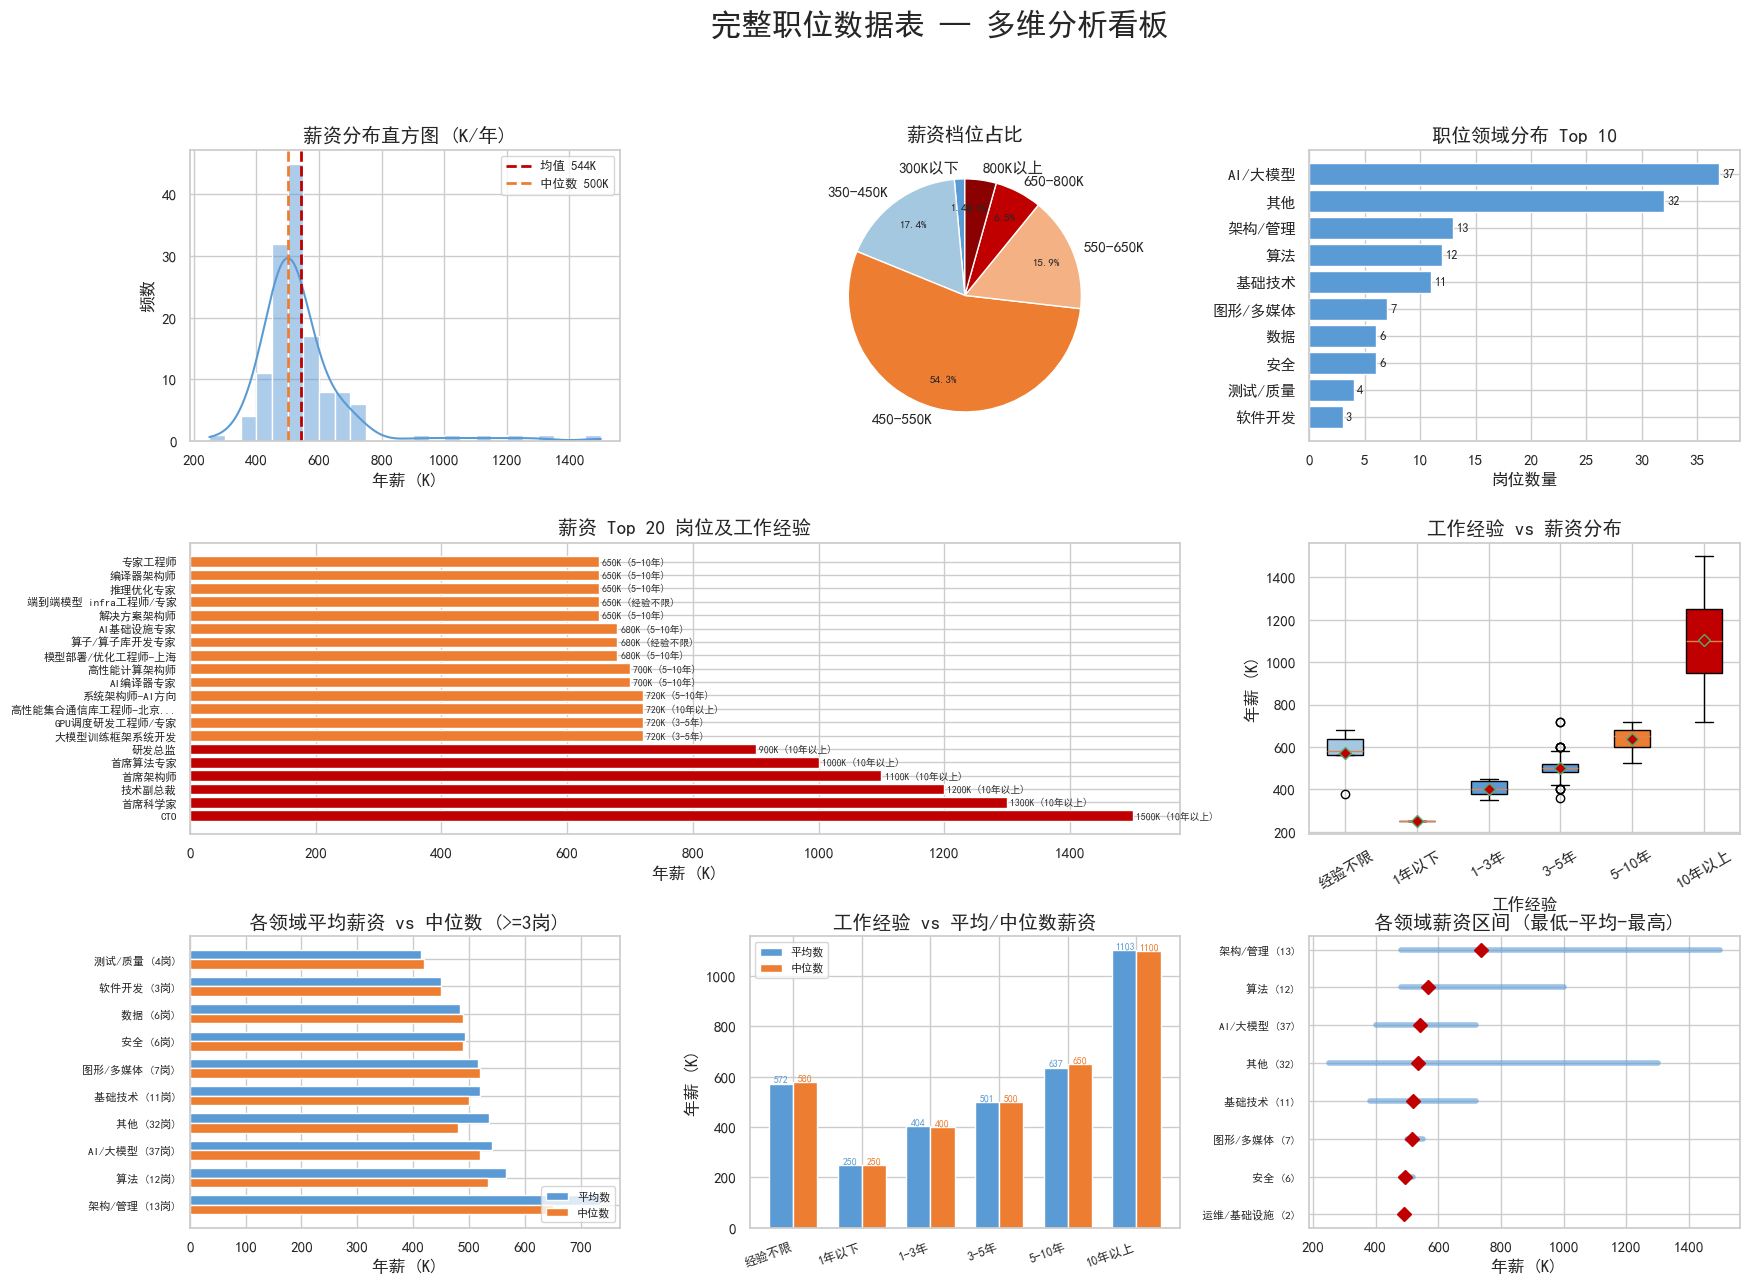


--- 分析摘要 ---
数据总量: 138 条，覆盖 15 个领域
薪资范围: 250K ~ 1500K
平均薪资: 544K
中位数薪资: 500K
最高薪岗位: CTO (1500K)
平均薪资最高领域: 架构/管理


In [5]:
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')
from matplotlib.gridspec import GridSpec

# --- 1. 基础配置 ---
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# --- 2. 读取数据 ---
df = pd.read_excel('2026国内boss直聘数据集.xlsx', sheet_name='职位数据')
print(f"数据集形状: {df.shape}")
print(f"数据量: {len(df)} 条")
print(f"\n前5行预览:")
print(df.head())
print(f"\n基本统计:")
print(df['年薪（K）'].describe())

# --- 3. 数据预处理 ---
# 3.1 职位领域分类
def classify_position(name):
    if not isinstance(name, str):
        return '其他'
    n = name
    if any(kw in n for kw in ['AI', '人工智能', '大模型', 'LLM', 'NLP', '自然语言', '机器学习', '深度学习', '强化学习', '神经网络']):
        return 'AI/大模型'
    if any(kw in n for kw in ['算法', '搜索', '推荐', '广告', '排序', '召回']):
        return '算法'
    if any(kw in n for kw in ['前端', '后端', '全栈', 'Web', 'web', 'Java', 'java', 'Python', 'python', 'C++', 'Golang', 'go', 'Rust', 'Node']):
        return '软件开发'
    if any(kw in n for kw in ['数据', '数据仓库', 'ETL', 'BI', '数仓', '数据分析', '数据挖掘']):
        return '数据'
    if any(kw in n for kw in ['安全', '渗透', '攻防', '信息安全', '网络安全']):
        return '安全'
    if any(kw in n for kw in ['运维', '运维', 'SRE', 'DevOps', 'devops', 'K8s', 'k8s', 'Kubernetes', 'Docker', '云', '基础设施']):
        return '运维/基础设施'
    if any(kw in n for kw in ['测试', 'QA', '质量']):
        return '测试/质量'
    if any(kw in n for kw in ['架构', 'Architect', '技术总监', 'CTO', 'Leader', 'leader', '负责人', '专家']):
        return '架构/管理'
    if any(kw in n for kw in ['GPU', 'HPC', '高性能', '芯片', '半导体', 'EDA', '编译', '驱动', '嵌入式', '硬件', 'FPGA', 'IC']):
        return '基础技术'
    if any(kw in n for kw in ['产品', 'Product', '运营', '策划']):
        return '产品/运营'
    if any(kw in n for kw in ['图形', '渲染', '游戏', '引擎', '3D', 'VR', 'AR', '元宇宙', '音视频', '视频', '图像', '视觉', '多模态']):
        return '图形/多媒体'
    if any(kw in n for kw in ['通信', '5G', '信号', '射频', '无线', '基带']):
        return '通信/信号'
    if any(kw in n for kw in ['量化', '交易', '金融科技', 'FinTech', '风控']):
        return '金融科技'
    if any(kw in n for kw in ['自动驾驶', '机器人', '无人机', '控制', 'SLAM', '感知', '规划']):
        return '自动驾驶/机器人'
    return '其他'

df['职位领域'] = df['职位名称'].apply(classify_position)

# 3.2 工作经验标准化
exp_order = ['经验不限', '1年以下', '1-3年', '3-5年', '5-10年', '10年以上']
df['工作经验'] = pd.Categorical(df['工作经验'], categories=exp_order, ordered=True)

# 3.3 薪资档位划分
df['薪资档位'] = pd.cut(
    df['年薪（K）'],
    bins=[0, 350, 450, 550, 650, 800, 2000],
    labels=['300K以下', '350-450K', '450-550K', '550-650K', '650-800K', '800K以上']
)

# --- 4. 可视化分析 ---
print(f"\n=== 职位领域分布 ===")
print(df['职位领域'].value_counts().to_string())
print(f"\n=== 薪资档位分布 ===")
print(df['薪资档位'].value_counts().to_string())

# 创建画布布局
fig = plt.figure(figsize=(20, 14))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.30)
fig.suptitle('完整职位数据表 — 多维分析看板', fontsize=22, y=0.98)

# ============================================================
# 图1：薪资分布直方图 + 核密度曲线
# ============================================================
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(df['年薪（K）'], kde=True, bins=25, color='#5B9BD5', edgecolor='white', ax=ax1)
ax1.axvline(df['年薪（K）'].mean(), color='#C00000', linestyle='--', linewidth=2, label=f"均值 {df['年薪（K）'].mean():.0f}K")
ax1.axvline(df['年薪（K）'].median(), color='#ED7D31', linestyle='--', linewidth=2, label=f"中位数 {df['年薪（K）'].median():.0f}K")
ax1.set_title('薪资分布直方图 (K/年)', fontsize=14)
ax1.set_xlabel('年薪 (K)')
ax1.set_ylabel('频数')
ax1.legend(fontsize=9)

# ============================================================
# 图2：薪资档位占比饼图
# ============================================================
ax2 = fig.add_subplot(gs[0, 1])
tier_counts = df['薪资档位'].value_counts().sort_index()
colors_pie = ['#5B9BD5', '#A5C8E1', '#ED7D31', '#F4B183', '#C00000', '#8B0000']
wedges, texts, autotexts = ax2.pie(
    tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
    startangle=90, colors=colors_pie, pctdistance=0.75
)
for t in autotexts:
    t.set_fontsize(8)
ax2.set_title('薪资档位占比', fontsize=14)

# ============================================================
# 图3：职位领域分布 (水平柱状图)
# ============================================================
ax3 = fig.add_subplot(gs[0, 2])
field_counts = df['职位领域'].value_counts().head(10)
bars = ax3.barh(range(len(field_counts)), field_counts.values, color='#5B9BD5')
ax3.set_yticks(range(len(field_counts)))
ax3.set_yticklabels(field_counts.index.tolist())
ax3.set_xlabel('岗位数量')
ax3.set_title('职位领域分布 Top 10', fontsize=14)
ax3.invert_yaxis()
for i, v in enumerate(field_counts.values):
    ax3.text(v + 0.3, i, str(v), va='center', fontsize=9, fontweight='bold')

# ============================================================
# 图4：Top 20 高薪岗位
# ============================================================
ax4 = fig.add_subplot(gs[1, :2])
top20 = df.nlargest(20, '年薪（K）')[['职位名称', '年薪（K）', '工作经验']].copy()
top20 = top20.sort_values('年薪（K）')
colors_top = ['#C00000' if v >= 800 else '#ED7D31' if v >= 600 else '#5B9BD5' for v in top20['年薪（K）'].values]
bars = ax4.barh(range(len(top20)), top20['年薪（K）'].values, color=colors_top)
ax4.set_yticks(range(len(top20)))
# 截断过长的职位名称
labels = [n[:25] + '...' if len(n) > 25 else n for n in top20['职位名称'].values]
ax4.set_yticklabels(labels, fontsize=8)
ax4.set_xlabel('年薪 (K)')
ax4.set_title('薪资 Top 20 岗位及工作经验', fontsize=14)
ax4.invert_yaxis()
for i, (_, row) in enumerate(top20.iterrows()):
    ax4.text(row['年薪（K）'] + 5, i, f"{row['年薪（K）']}K ({row['工作经验']})", va='center', fontsize=7, color='#333333')

# ============================================================
# 图5：工作经验 vs 薪资 (箱线图)
# ============================================================
ax5 = fig.add_subplot(gs[1, 2])
exp_data = [df[df['工作经验'] == e]['年薪（K）'].values for e in exp_order]
bp = ax5.boxplot(exp_data, labels=exp_order, patch_artist=True, showmeans=True,
                  meanprops=dict(marker='D', markerfacecolor='#C00000', markersize=6))
colors_exp = ['#A5C8E1', '#A5C8E1', '#5B9BD5', '#5B9BD5', '#ED7D31', '#C00000']
for patch, color in zip(bp['boxes'], colors_exp):
    patch.set_facecolor(color)
ax5.set_title('工作经验 vs 薪资分布', fontsize=14)
ax5.set_xlabel('工作经验')
ax5.set_ylabel('年薪 (K)')
ax5.tick_params(axis='x', rotation=30)

# ============================================================
# 图6：职位领域平均薪资对比
# ============================================================
ax6 = fig.add_subplot(gs[2, 0])
field_salary = df.groupby('职位领域', observed=False).agg(
    job_count=('职位名称', 'count'),
    avg_salary=('年薪（K）', 'mean'),
    med_salary=('年薪（K）', 'median')
).query('job_count >= 3').sort_values('avg_salary', ascending=True)

x = range(len(field_salary))
width = 0.35
ax6.barh([i - width/2 for i in x], field_salary['avg_salary'].values, width,
         label='平均数', color='#5B9BD5')
ax6.barh([i + width/2 for i in x], field_salary['med_salary'].values, width,
         label='中位数', color='#ED7D31')
ax6.set_yticks(x)
ax6.set_yticklabels([f"{n} ({c}岗)" for n, c in zip(field_salary.index, field_salary['job_count'].values)], fontsize=8)
ax6.set_xlabel('年薪 (K)')
ax6.set_title('各领域平均薪资 vs 中位数 (>=3岗)', fontsize=14)
ax6.legend(fontsize=8, loc='lower right')
ax6.invert_yaxis()

# ============================================================
# 图7：工作经验 vs 薪资 (均值对比)
# ============================================================
ax7 = fig.add_subplot(gs[2, 1])
exp_stats = df.groupby('工作经验', observed=False)['年薪（K）'].agg(['mean', 'median', 'count']).reset_index()
x = range(len(exp_stats))
width = 0.35
ax7.bar([i - width/2 for i in x], exp_stats['mean'].values, width, label='平均数', color='#5B9BD5')
ax7.bar([i + width/2 for i in x], exp_stats['median'].values, width, label='中位数', color='#ED7D31')
ax7.set_xticks(x)
ax7.set_xticklabels(exp_stats['工作经验'].values, rotation=20, ha='right', fontsize=9)
ax7.set_ylabel('年薪 (K)')
ax7.set_title('工作经验 vs 平均/中位数薪资', fontsize=14)
ax7.legend(fontsize=8)
for i, (_, row) in enumerate(exp_stats.iterrows()):
    if row['count'] > 0:
        ax7.text(i - width/2, row['mean'] + 3, f"{row['mean']:.0f}", ha='center', fontsize=7, color='#5B9BD5')
        ax7.text(i + width/2, row['median'] + 3, f"{row['median']:.0f}", ha='center', fontsize=7, color='#ED7D31')

# ============================================================
# 图8：各领域最低/最高/平均薪资区间
# ============================================================
ax8 = fig.add_subplot(gs[2, 2])
field_range = df.groupby('职位领域', observed=False).agg(
    min_salary=('年薪（K）', 'min'),
    avg_salary=('年薪（K）', 'mean'),
    max_salary=('年薪（K）', 'max'),
    count=('职位名称', 'count')
).query('count >= 2').sort_values('avg_salary')

field_range_short = field_range.tail(8)
for i, (_, row) in enumerate(field_range_short.iterrows()):
    ax8.plot([row['min_salary'], row['max_salary']], [i, i], color='#5B9BD5', linewidth=4, alpha=0.6)
    ax8.plot(row['avg_salary'], i, 'D', color='#C00000', markersize=7)
ax8.set_yticks(range(len(field_range_short)))
ax8.set_yticklabels([f"{n} ({c})" for n, c in zip(field_range_short.index, field_range_short['count'].values)], fontsize=8)
ax8.set_xlabel('年薪 (K)')
ax8.set_title('各领域薪资区间 (最低-平均-最高)', fontsize=14)

plt.tight_layout()
plt.show()

print("\n--- 分析摘要 ---")
print(f"数据总量: {len(df)} 条，覆盖 {df['职位领域'].nunique()} 个领域")
print(f"薪资范围: {df['年薪（K）'].min():.0f}K ~ {df['年薪（K）'].max():.0f}K")
print(f"平均薪资: {df['年薪（K）'].mean():.0f}K")
print(f"中位数薪资: {df['年薪（K）'].median():.0f}K")
print(f"最高薪岗位: {df.loc[df['年薪（K）'].idxmax(), '职位名称']} ({df['年薪（K）'].max():.0f}K)")
top_domain = field_salary.index[-1] if len(field_salary) > 0 else 'N/A'
print(f"平均薪资最高领域: {top_domain}")
